In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.width', 120)

In [5]:
# Load the raw dataset from the group repository structure
df = pd.read_csv('../data/raw/data.csv')

# Strip hidden spaces from column names
df.columns = df.columns.str.strip()

print(f"Initial Dataset Shape: {df.shape}")

Initial Dataset Shape: (6819, 96)


In [6]:
# 1. Check for exact duplicate rows
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Dropped {duplicate_count} duplicate rows.")
else:
    print("No duplicate rows found.")

# 2. Check for true missing values (NaN)
missing_total = df.isnull().sum().sum()
print(f"Total True Missing Values (NaN): {missing_total}")

# 3. Check for fake placeholders (-999 or 9999)
placeholders = (df == -999).sum().sum() + (df == -9999).sum().sum()
print(f"Total Placeholder Values (-999): {placeholders}")

No duplicate rows found.
Total True Missing Values (NaN): 0
Total Placeholder Values (-999): 0


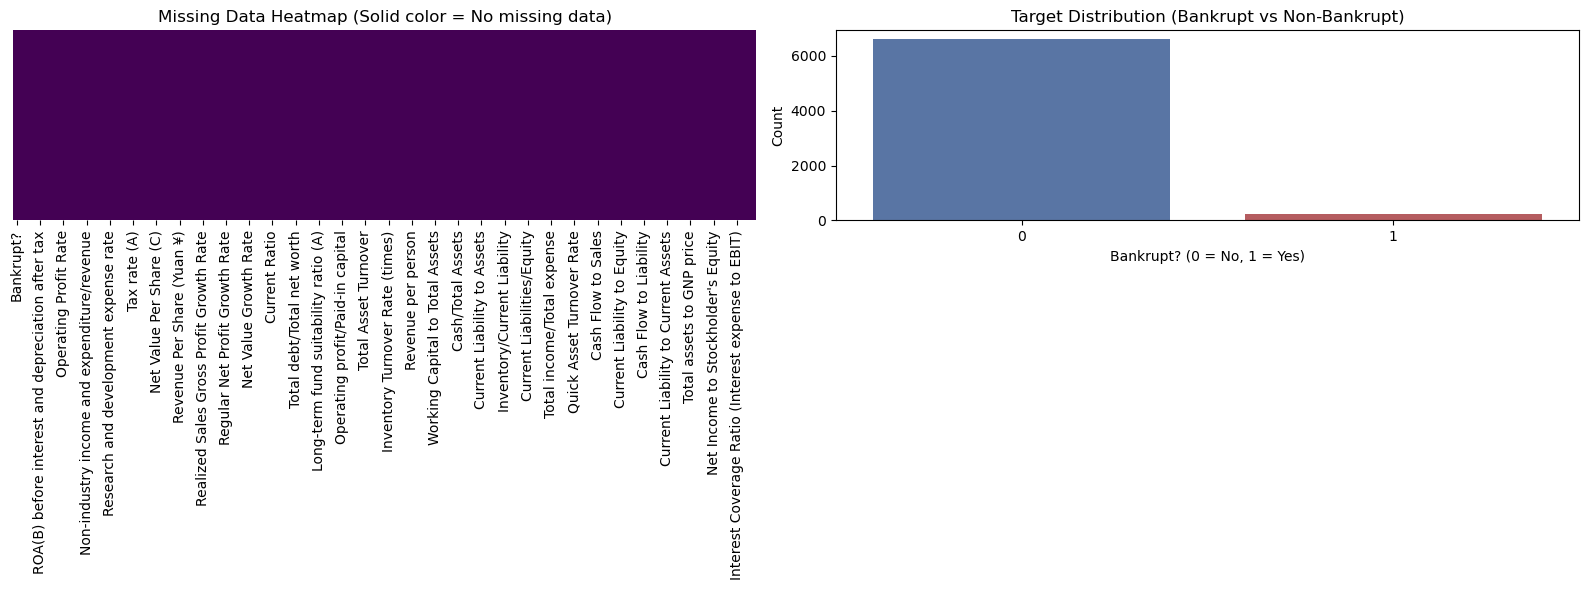

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visual 1: Missing Data Heatmap
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Data Heatmap (Solid color = No missing data)')

# Visual 2: Target Distribution Bar Chart
# FIX 1: Added hue and legend=False to silence the Seaborn warning
sns.countplot(data=df, x='Bankrupt?', hue='Bankrupt?', palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[1])
axes[1].set_title('Target Distribution (Bankrupt vs Non-Bankrupt)')
axes[1].set_xlabel('Bankrupt? (0 = No, 1 = Yes)')
axes[1].set_ylabel('Count')

# FIX 2: Added ../ to the file path so it saves outside the notebooks folder
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member1_data_quality.png', dpi=120)
plt.show()

In [11]:
# Separate features and target
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

# Split 80/20, using stratify to keep the rare bankruptcy cases balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Reattach target for clean handoff
train_clean = X_train.copy()
train_clean['Bankrupt?'] = y_train

test_clean = X_test.copy()
test_clean['Bankrupt?'] = y_test

# Export to intermediate pipeline files
train_clean.to_csv('../data/train_clean.csv', index=False)
test_clean.to_csv('../data/test_clean.csv', index=False)

print(f"Exported Train Set Shape: {train_clean.shape}")
print(f"Exported Test Set Shape: {test_clean.shape}")

Exported Train Set Shape: (5455, 96)
Exported Test Set Shape: (1364, 96)
